# Saddle-to-saddle learning: where moved beliefs beat backpropagation

Deep networks trained from a small initialisation do not descend their loss
smoothly: they crawl along a sequence of saddle points, long plateaus where
the gradient nearly vanishes, punctuated by sudden drops as one feature after
another is learnt. Predictive coding has been argued to escape such plateaus
sooner than backpropagation: by first inferring what the hidden activities
should be and only then updating the weights (*prospective configuration*,
{cite:p}`Song2024`), its weight updates keep a nonzero drive in regions where
the plain gradient is flat {cite:p}`innocenti:2024`.

The [theory page](./0.5-Deep_networks_theory.md) locates both behaviours on
one axis: the precision ratio $r = \hat{\pi}/\pi$ of the interior beliefs.
At $r \equiv 1$ the interior is silent and the precision-weighted update
reproduces backpropagation node for node; as $r$ falls the beliefs
genuinely reconfigure toward the target before the weights move. This
notebook drives along that axis on a task built to contain many
saddle-to-saddle transitions, and measures who escapes when. The
[input-precision notebook](./0.10-Input_precision.ipynb) characterised the
dial this experiment exploits.

Both learners are the same network, the same initialisation, the same data,
and the same single-sweep updates; they differ in one argument:

- **backpropagation arm**: `learning_kind="precision_weighted"`, which
  reproduces the backpropagated gradient exactly, at any precision setting;
- **predictive coding arm**: `learning_kind="standard"`, the local rule on
  *moved* beliefs $g = \delta \otimes a$, with loose interior priors so
  the beliefs move by $O(1)$; a moved belief shifts by (routed error)
  $/\,\pi$, so a small interior precision amplifies the update drive with
  nothing cancelling it.

pyhgf performs one bottom-up inference sweep per update rather than a full
relaxation to equilibrium, so this is a single-sweep rendering of
prospective configuration; the equilibrium schemes of
{cite:p}`Song2024` and {cite:p}`innocenti:2024` should only widen what is
measured here.

In [1]:
import dataclasses

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from pyhgf.model import DeepNetwork

plt.rcParams["figure.constrained_layout.use"] = True
rng = np.random.default_rng(11)

## 1. A task made of saddles

The canonical saddle generator is the deep **linear** teacher and student.
The teacher is one matrix $M = U \Sigma V^\top$ with a graded spectrum of
singular values; gradient descent on a deep linear student learns the
singular modes *sequentially*, one plateau per mode, with escape times
ordered by $1/\sigma_i$. Six well-separated values give six saddles per
run.

The student is a three-matrix linear chain, narrower than it is deep in
spirit: identity coupling, no volatility levels, no bias columns (biases
blur the saddle structure). Initialising every matrix at scale
$\varepsilon \ll 1$ parks the network near the origin saddle, where the
staircase starts. The output layer keeps the unit observation precision;
the interior prior precision $\pi_h$ is the experimental dial; the input
layer is trusted ($\pi_x = 100$), which keeps the interior's expected
precision equal to its prior throughout training. The confidence updates
stay off so the precision landscape is stationary and the mechanism
isolated.

In [2]:
D_IN, D_OUT, WIDTH = 16, 8, 12
SIZES = [D_OUT, WIDTH, WIDTH, D_IN]  # bottom (output) first: three matrices
SIGMA = np.array([4.0, 2.0, 1.0, 0.5, 0.25, 0.125], dtype="float32")

U = np.linalg.qr(rng.normal(size=(D_OUT, D_OUT)))[0][:, : len(SIGMA)].astype(
    "float32"
)
V = np.linalg.qr(rng.normal(size=(D_IN, D_IN)))[0][:, : len(SIGMA)].astype(
    "float32"
)
M = (U * SIGMA) @ V.T
X = rng.normal(size=(512, D_IN)).astype("float32")  # full batch, reused
Y = X @ M.T


def build(eps, pi_hidden=1.0, pi_x=100.0, seed=0):
    """A linear chain student initialised at scale ``eps``."""
    net = DeepNetwork()
    net.add_layer(
        size=SIZES[0], volatility_parent=False, add_constant_input=False
    )
    for width in SIZES[1:-1]:
        net.add_layer(
            size=width, volatility_parent=False, add_constant_input=False,
            precision=pi_hidden, expected_precision=pi_hidden,
        )
    net.add_layer(
        size=SIZES[-1], volatility_parent=False, add_constant_input=False,
        precision=pi_x, expected_precision=pi_x,
    )
    r = np.random.default_rng(seed)
    layers = list(net.state.layers)
    new_layers = [layers[0]]
    for layer in layers[1:]:
        shape = layer.weights_in.shape
        w = (eps * r.normal(size=shape) / np.sqrt(shape[1])).astype("float32")
        new_layers.append(dataclasses.replace(layer, weights_in=jnp.asarray(w)))
    net.state = dataclasses.replace(net.state, layers=tuple(new_layers))
    return net


def end_to_end(net):
    """The student's end-to-end map, the product of its weight matrices."""
    weights = [np.asarray(layer.weights_in) for layer in net.state.layers[1:]]
    m = weights[0]
    for w in weights[1:]:
        m = m @ w
    return m


def train(kind, lr, pi_hidden=1.0, eps=1e-2, n_steps=8000, every=20):
    """Train one arm and record loss and per-mode strengths over steps."""
    net = build(eps, pi_hidden=pi_hidden)
    opt = optax.sgd(lr)
    steps, losses, modes = [], [], []
    for t in range(n_steps):
        net.batch_update(
            X, Y, optimizer=opt, learning_kind=kind, update_confidences=False
        )
        if t % every == 0 or t == n_steps - 1:
            m = end_to_end(net)
            steps.append(t)
            losses.append(float(((X @ m.T - Y) ** 2).mean()))
            modes.append(np.einsum("ij,ik,jk->k", m, U, V) / SIGMA)
    return {
        "steps": np.array(steps),
        "loss": np.array(losses),
        "modes": np.array(modes),
    }


def escape_times(run, thr=0.5):
    """First recorded step at which each mode strength exceeds ``thr``."""
    out = []
    for k in range(len(SIGMA)):
        above = np.flatnonzero(run["modes"][:, k] > thr)
        out.append(int(run["steps"][above[0]]) if above.size else None)
    return out


MODE_COLORS = sns.color_palette("viridis", len(SIGMA))

## 2. The staircase

The backpropagation arm at its stable learning rate shows the classic
picture: the loss descends in steps, and the mode strengths
$a_i(t) = u_i^\top \hat{M}(t)\, v_i / \sigma_i$ rise one after another,
each transition preceded by a plateau several times longer than the last
(the escape time scales with $1/\sigma_i$).

backpropagation escape times: [60, 260, 1220, 5980, None, None]


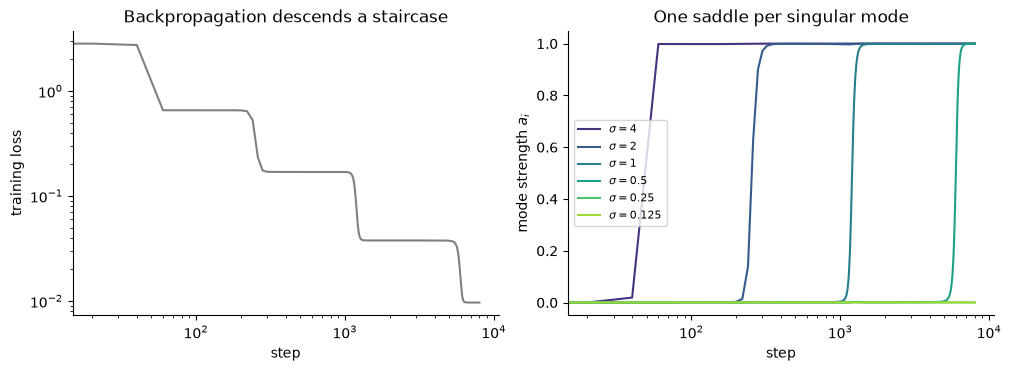

In [3]:
bp = train("precision_weighted", lr=0.01)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.plot(bp["steps"], bp["loss"], color="grey")
ax1.set(
    xlabel="step", ylabel="training loss", xscale="log", yscale="log",
    title="Backpropagation descends a staircase",
)
for k in range(len(SIGMA)):
    ax2.plot(
        bp["steps"], bp["modes"][:, k], color=MODE_COLORS[k],
        label=rf"$\sigma = {SIGMA[k]:g}$",
    )
ax2.set(
    xlabel="step", ylabel=r"mode strength $a_i$", xscale="log",
    title="One saddle per singular mode",
)
ax2.legend(fontsize=8)
sns.despine()
print("backpropagation escape times:", escape_times(bp))

## 3. Loosening the interior: the same transitions, earlier

Holding everything fixed (learning rate included) and lowering the interior
prior precision moves the learner along the $r$ axis, away from
backpropagation and toward prospective configuration. With $\pi_h = 1$ the
moved beliefs shift by roughly the routed error and the standard rule stays
close to the backpropagation arm near the origin; with $\pi_h = 0.1$ every
belief movement is amplified tenfold, and the weight drive on the plateau
grows accordingly. The transitions shift left, most strongly the first
one.

pi_h =  1.0: escape times [160, 1280, None, None, None, None]
pi_h =  0.3: escape times [60, 540, None, None, None, None]
pi_h =  0.1: escape times [20, 300, 2080, None, None, None]
backprop (same lr): escape times [140, 820, None, None, None, None]


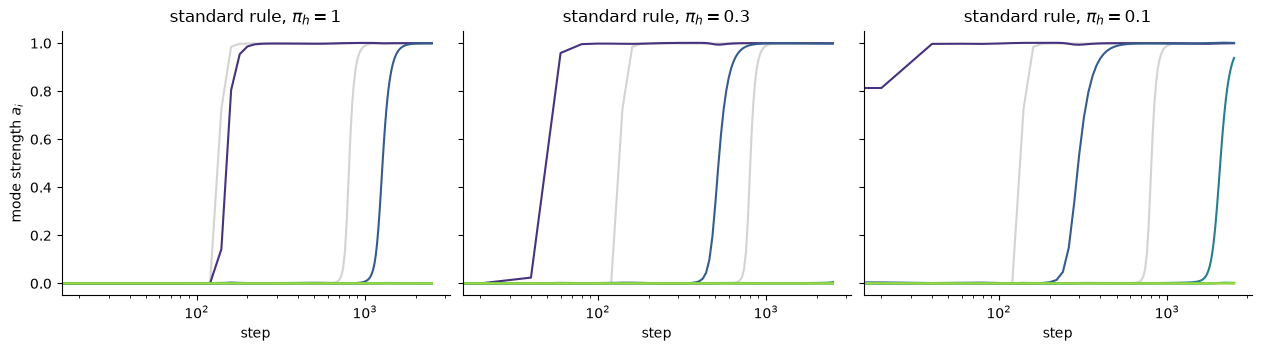

In [4]:
PI_GRID = [1.0, 0.3, 0.1]
dial = {
    pi: train("standard", lr=3e-3, pi_hidden=pi, n_steps=2500)
    for pi in PI_GRID
}
bp_matched = train("precision_weighted", lr=3e-3, n_steps=2500)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
for ax, pi in zip(axes, PI_GRID):
    for k in range(len(SIGMA)):
        ax.plot(
            bp_matched["steps"], bp_matched["modes"][:, k],
            color="lightgrey", zorder=0,
        )
        ax.plot(dial[pi]["steps"], dial[pi]["modes"][:, k],
                color=MODE_COLORS[k])
    ax.set(
        xlabel="step", xscale="log",
        title=rf"standard rule, $\pi_h = {pi:g}$",
    )
axes[0].set(ylabel=r"mode strength $a_i$")
sns.despine()
for pi in PI_GRID:
    print(f"pi_h = {pi:>4}: escape times {escape_times(dial[pi])}")
print(f"backprop (same lr): escape times {escape_times(bp_matched)}")

## 4. Best against best, and an honest crossover

A matched learning rate favours no one, but each learner should also be
allowed its own best stable rate. Backpropagation diverges at the first
transition beyond $\eta = 0.01$; the predictive coding arm is stable at
$0.01$ as well, so the comparison below is best against best. Predictive
coding leaves the first saddle several times sooner and keeps a shrinking
lead over the next two; by the fourth mode it has fallen behind.

The reversal is the mechanism seen from the other side. The amplification
that drives early escapes is $1/\pi$ of the *posterior* interior belief,
and the posterior precision is the prior plus a bottom-up term that grows
with the weights. Near the origin that term is negligible and the
amplification is full; once several modes are learnt the weights are
$O(1)$, the bottom-up precision dominates, $r$ climbs back toward one, and
the standard rule loses its edge over the plain gradient. Single-sweep
prospective configuration spends its advantage exactly where
backpropagation crawls slowest: on the flattest early saddles.

escape step per mode (best stable lr, both 0.01):
  mode   sigma  backprop  pred. coding
     1     4.0        60            20
     2     2.0       260           180
     3     1.0      1220          1040
     4     0.5      5980          7680
     5    0.25      None          None
     6   0.125      None          None


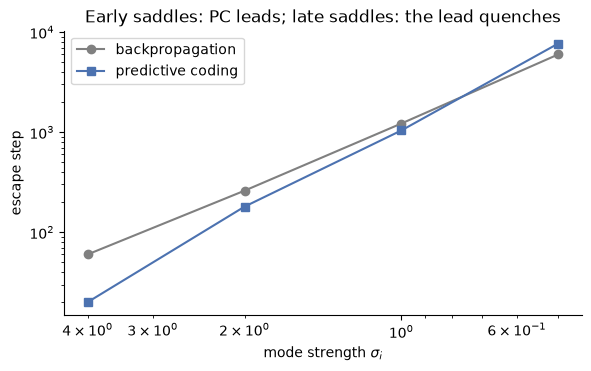

In [5]:
pc_best = train("standard", lr=0.01, pi_hidden=0.1, n_steps=8000)

bp_times = escape_times(bp)
pc_times = escape_times(pc_best)
print("escape step per mode (best stable lr, both 0.01):")
print(f"{'mode':>6} {'sigma':>7} {'backprop':>9} {'pred. coding':>13}")
for k in range(len(SIGMA)):
    print(
        f"{k + 1:>6} {SIGMA[k]:>7} {str(bp_times[k]):>9} "
        f"{str(pc_times[k]):>13}"
    )

fig, ax = plt.subplots(figsize=(5.8, 3.6))
learned = [k for k in range(len(SIGMA)) if bp_times[k] and pc_times[k]]
ax.plot(
    [SIGMA[k] for k in learned], [bp_times[k] for k in learned],
    marker="o", color="grey", label="backpropagation",
)
ax.plot(
    [SIGMA[k] for k in learned], [pc_times[k] for k in learned],
    marker="s", color="#4c72b0", label="predictive coding",
)
ax.set(
    xscale="log", yscale="log", xlabel=r"mode strength $\sigma_i$",
    ylabel="escape step",
    title="Early saddles: PC leads; late saddles: the lead quenches",
)
ax.invert_xaxis()
ax.legend()
sns.despine()

## 5. The smaller the initialisation, the larger the lead

The origin plateau lengthens as the initialisation scale shrinks, for both
learners, but not at the same rate: at a matched learning rate the
backpropagation arm pays roughly three times more steps per decade of
$\varepsilon$ than the predictive coding arm. The regime where
backpropagation is slowest is the regime where moved beliefs help most.

eps = 0.1: backprop 30, predictive coding 5
eps = 0.01: backprop 45, predictive coding 10
eps = 0.001: backprop 65, predictive coding 15
eps = 0.0001: backprop 80, predictive coding 20


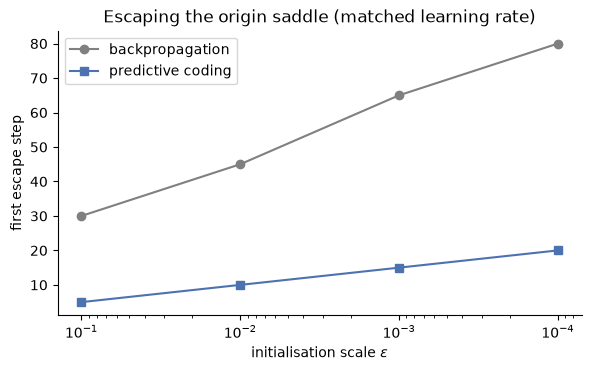

In [6]:
def first_escape(kind, lr, eps, pi_hidden=1.0, max_steps=20000, thr=0.5):
    net = build(eps, pi_hidden=pi_hidden)
    opt = optax.sgd(lr)
    for t in range(max_steps):
        net.batch_update(
            X, Y, optimizer=opt, learning_kind=kind, update_confidences=False
        )
        if t % 5 == 0:
            a1 = float(
                np.einsum("ij,ik,jk->k", end_to_end(net), U, V)[0] / SIGMA[0]
            )
            if a1 > thr:
                return t
    return None


eps_grid = [1e-1, 1e-2, 1e-3, 1e-4]
esc_bp = [first_escape("precision_weighted", 0.01, e) for e in eps_grid]
esc_pc = [first_escape("standard", 0.01, e, pi_hidden=0.1) for e in eps_grid]

fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(eps_grid, esc_bp, marker="o", color="grey", label="backpropagation")
ax.plot(eps_grid, esc_pc, marker="s", color="#4c72b0",
        label="predictive coding")
ax.set(
    xscale="log", xlabel=r"initialisation scale $\varepsilon$",
    ylabel="first escape step",
    title="Escaping the origin saddle (matched learning rate)",
)
ax.invert_xaxis()
ax.legend()
sns.despine()
for e, tb, tp in zip(eps_grid, esc_bp, esc_pc):
    print(f"eps = {e:g}: backprop {tb}, predictive coding {tp}")

## 6. Reading the results

- **The task is the microscope.** A graded singular spectrum turns one
  training run into a sequence of measurable saddle escapes; a small
  initialisation stretches the plateaus where the learners differ.
- **One knob separates the learners.** Both arms run the same sweeps on the
  same network; `precision_weighted` cancels the belief movement and is
  backpropagation exactly, `standard` keeps it, and the interior prior
  precision sets how much movement there is to keep. The comparison is
  therefore about the geometry of the update, not about implementation
  details.
- **The advantage is real, early, and self-limiting.** Moved beliefs escape
  the origin saddle several times sooner, with a threefold shallower growth
  of escape time as the initialisation shrinks; the lead narrows as learnt
  structure raises the bottom-up precision and $r$ returns to one. That
  quenching is not a flaw of the demonstration: it is the framework's own
  statement that a confident, structured network has nothing left to gain
  from reconfiguring, at which point predictive coding and backpropagation
  agree.
- **Scope.** Everything here is single-sweep, linear, and plain gradient
  descent by design: adaptive optimisers absorb much of the plateau
  problem on their own, residual connections remove the saddles this task
  is built from, and a full relaxation to the prospective equilibrium
  ({cite:p}`Song2024`, {cite:p}`innocenti:2024`) would be expected to
  extend the lead beyond what one bottom-up sweep achieves.
